# Experiment 2 — Preprocessing Levels and Representation Quality

This notebook investigates how different levels of preprocessing influence the predictive performance of machine learning models with different inductive biases and levels of complexity.

The experiment compares three preprocessing conditions:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

The purpose of the experiment is to examine whether improvements in data representation can reduce the performance gap between simpler classical machine learning models and more flexible neural network models.

Personally, I find this experiment particularly important because preprocessing is often treated as a secondary technical step in machine learning workflows. However, throughout previous projects, I repeatedly noticed how relatively small representation changes could dramatically influence model behavior. This experiment attempts to investigate that relationship more systematically.

## Project Path Configuration

The notebook explicitly adds the project root directory to the Python path in order to ensure that the centralized experimental framework within the `src/` directory can be imported consistently across notebooks.

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

## Importing the Experimental Framework

The notebook imports the centralized modules responsible for dataset loading, preprocessing configuration, model definition, experiment execution, visualization, and result saving.

In [2]:
from sklearn.model_selection import (
    train_test_split
)

from src.data.load_data import (
    load_adult_dataset
)

from src.data.preprocessing import (
    get_feature_types,
    create_raw_preprocessor,
    create_cleaned_preprocessor,
    create_engineered_preprocessor
)

from src.models.model_definitions import (
    get_models
)

from src.experiments.run_experiment import (
    run_experiment
)

from src.visualization.plots import (
    plot_f1_comparison
)

from src.visualization.summaries import (
    save_summary_table
)

from src.utils.saving import (
    save_metrics
)

## Dataset Loading

The Adult Income dataset is loaded through the centralized data-loading module in order to ensure consistency across experiments.

In [3]:
X, y = load_adult_dataset()

## Feature Type Identification

Numerical and categorical features are identified separately in order to support preprocessing pipeline construction.

In [4]:
numeric_cols, categorical_cols = get_feature_types(X)

## Train-Test Split

The dataset is divided into training and test subsets using stratified sampling in order to preserve class distribution across both subsets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Preprocessing Configurations

The experiment compares three preprocessing levels representing increasing degrees of representation refinement:
- Raw preprocessing
- Cleaned preprocessing
- Engineered preprocessing

This staged structure allows the experiment to examine how incremental improvements in representation quality influence model behavior.

In [6]:
preprocessing_levels = {
    
    "Raw": create_raw_preprocessor(
        numeric_cols,
        categorical_cols
    ),
    
    "Cleaned": create_cleaned_preprocessor(
        numeric_cols,
        categorical_cols
    ),
    
    "Engineered": create_engineered_preprocessor(
        numeric_cols,
        categorical_cols
    )
}

## Model Definitions

The experiment compares models representing different levels of complexity and different inductive biases.

In [7]:
models = get_models()

## Running the Preprocessing Experiment

The experiment is executed through the centralized experiment runner in order to ensure consistent preprocessing, training, and evaluation procedures across all preprocessing conditions and models.

In [8]:
results_df = run_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    preprocessing_levels,
    models
)

results_df


=== Raw Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...
Training MLP...



=== Cleaned Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


...


=== Engineered Preprocessing ===
Training Logistic Regression...


Training Decision Tree...


Training Naive Bayes...


Training MLP...


,preprocessing,model,accuracy,f1_score,roc_auc
0,Raw,Logistic Regression,0.782782,0.406267,0.626715
1,Raw,Decision Tree,0.817586,0.622937,0.753165
2,Raw,Naive Bayes,0.797113,0.421483,0.834841
3,Raw,MLP,0.814822,0.511477,0.814207
4,Cleaned,Logistic Regression,0.806940,0.676501,0.904395
5,Cleaned,Decision Tree,0.817177,0.621931,0.752456
6,Cleaned,Naive Bayes,0.620432,0.537425,0.828695
7,Cleaned,MLP,0.834272,0.658799,0.884180
8,Engineered,Logistic Regression,0.797113,0.665767,0.898619
9,Engineered,Decision Tree,0.814720,0.613248,0.746020


## Saving Experimental Results

The experimental results are saved to the centralized results directory structure in order to support reproducibility and later cross-experiment analysis.

In [9]:
save_metrics(
    results_df,
    "preprocessing_levels_results.csv"
)

Metrics saved to: ../results/metrics/preprocessing_levels_results.csv


## Preprocessing Performance Visualization

The following figure compares model performance across preprocessing levels.

Plot saved to: ../results/plots/preprocessing_levels_f1_comparison.png


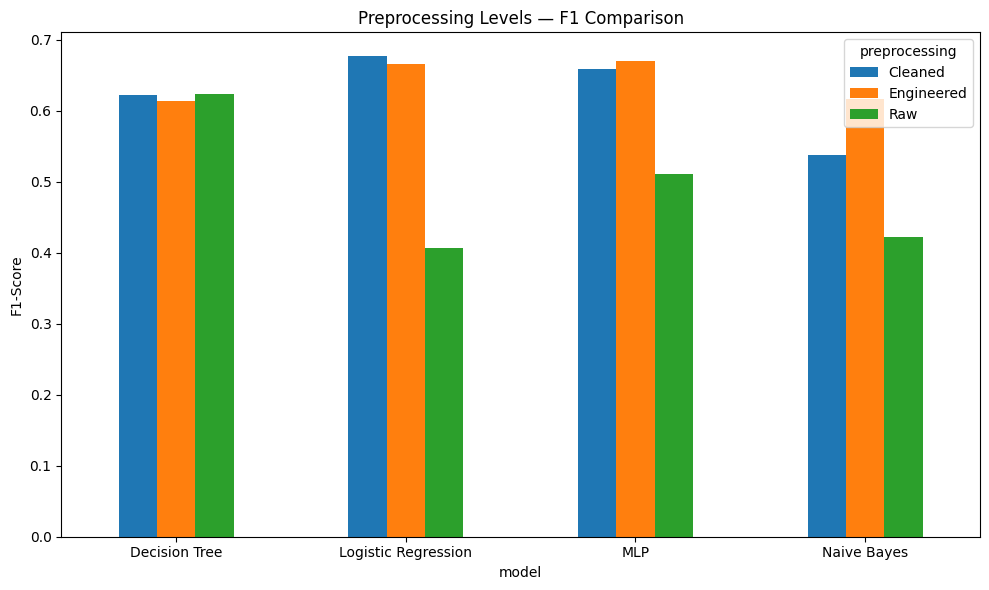

In [10]:
plot_f1_comparison(
    results_df,
    title="Preprocessing Levels — F1 Comparison",
    filename="preprocessing_levels_f1_comparison.png"
)

## Summary Table

A summary table is generated in order to support later cross-experiment comparison and thesis reporting.

In [11]:
summary_table = save_summary_table(
    results_df,
    metric="f1_score",
    filename="preprocessing_levels_summary_table.csv"
)

summary_table

Table saved to: ../results/tables/preprocessing_levels_summary_table.csv


,model,preprocessing,f1_score
0,Decision Tree,Cleaned,0.621931
1,Decision Tree,Engineered,0.613248
2,Decision Tree,Raw,0.622937
3,Logistic Regression,Cleaned,0.676501
4,Logistic Regression,Engineered,0.665767
5,Logistic Regression,Raw,0.406267
6,MLP,Cleaned,0.658799
7,MLP,Engineered,0.670526
8,MLP,Raw,0.511477
9,Naive Bayes,Cleaned,0.537425


## Interpretation of Preprocessing Results

The preprocessing experiment reveals substantial differences in how models respond to improvements in data representation.

One of the clearest findings is that preprocessing quality has a major influence on predictive performance for several models, particularly Logistic Regression, Naive Bayes, and the Multi-Layer Perceptron (MLP). In contrast, Decision Trees remain comparatively stable across preprocessing conditions.

Logistic Regression demonstrates one of the strongest responses to preprocessing improvements. Under raw preprocessing conditions, performance is substantially weaker, while cleaned preprocessing dramatically improves predictive quality. This suggests that linear models may depend heavily on representation quality and feature scaling in order to align effectively with the underlying structure of the data.

The MLP also demonstrates substantial sensitivity to preprocessing quality. Although the neural network performs reasonably well under raw preprocessing conditions, engineered preprocessing produces the strongest overall performance observed in the experiment. This suggests that flexible neural network architectures may still benefit considerably from carefully refined feature representations.

Naive Bayes demonstrates a particularly interesting pattern. While baseline performance under cleaned preprocessing remains comparatively weak, engineered preprocessing substantially improves predictive performance. One possible interpretation is that feature selection and representation refinement reduce noisy or redundant structure, thereby improving alignment with the conditional independence assumptions embedded within the model.

Decision Trees remain comparatively stable across preprocessing levels, suggesting relative robustness to representation changes. At the same time, their overall predictive performance remains slightly below the strongest-performing models.

Personally, I found it especially interesting that preprocessing improvements frequently produced larger performance changes than differences in model complexity alone. In several cases, relatively simple models became highly competitive once the representation quality of the data improved.

Overall, the results increasingly support the broader motivation of the project: representation quality and preprocessing effectiveness may play a central role in determining predictive performance in tabular machine learning tasks, sometimes reducing the need for substantially more complex models.